In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
class Linear:

    def __init__(self):
        self.w = np.random.randn()
        self.b = 0.0

    def forward(self, x):
        self.x = x
        return self.w * x + self.b

    def backward(self, dL_dy):
        # Gradients of the loss with respect to w and b
        self.dw = torch.mean(dL_dy * self.x)
        self.db = torch.mean(dL_dy)

    def update(self, learning_rate):
        self.w -= learning_rate * self.dw
        self.b -= learning_rate * self.db

In [6]:
data = pd.DataFrame({
    "size_m2": [45, 55, 60, 70, 80, 90, 100, 120, np.nan],
    "rooms":  [1, 2, 2, 3, 3, 4, 4, 5, 6],
    "price":  [180, 210, 230, 270, 310, 350, 390, 450, 500]
})

data.head()

,size_m2,rooms,price
0,45.0,1,180
1,55.0,2,210
2,60.0,2,230
3,70.0,3,270
4,80.0,3,310


In [7]:
data.isna().sum()

size_m2    1
rooms      0
price      0
dtype: int64

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   size_m2  8 non-null      float64
 1   rooms    9 non-null      int64  
 2   price    9 non-null      int64  
dtypes: float64(1), int64(2)
memory usage: 348.0 bytes


In [9]:
data.describe()

,size_m2,rooms,price
count,8.000000,9.000000,9.000000
mean,77.500000,3.333333,321.111111
std,25.071327,1.581139,110.390720
min,45.000000,1.000000,180.000000
25%,58.750000,2.000000,230.000000
50%,75.000000,3.000000,310.000000
75%,92.500000,4.000000,390.000000
max,120.000000,6.000000,500.000000


In [10]:
data = data.dropna()

In [11]:
data["size_m2"].mean()

np.float64(77.5)

In [12]:
data["price"].max()

np.int64(450)

In [13]:
data.sort_values("price")

,size_m2,rooms,price
0,45.0,1,180
1,55.0,2,210
2,60.0,2,230
3,70.0,3,270
4,80.0,3,310
5,90.0,4,350
6,100.0,4,390
7,120.0,5,450


<Axes: xlabel='size_m2', ylabel='price'>

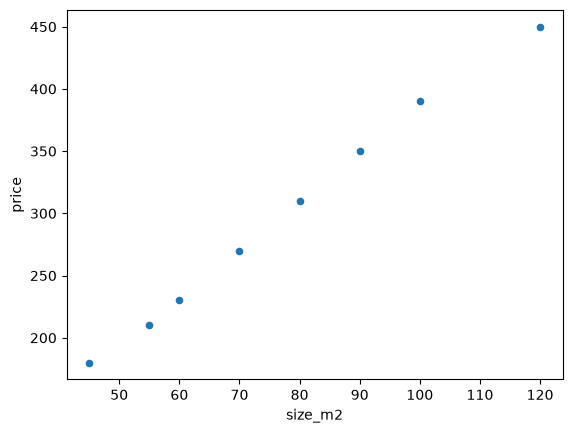

In [14]:
data.plot.scatter(x="size_m2", y="price")

In [15]:
# Linear Regression

In [16]:
x = torch.tensor(data["size_m2"].values, dtype=torch.float32)
y = torch.tensor(data["price"].values, dtype=torch.float32)

In [17]:
x

tensor([ 45.,  55.,  60.,  70.,  80.,  90., 100., 120.])

In [18]:
y

tensor([180., 210., 230., 270., 310., 350., 390., 450.])

In [ ]:
model = Linear()

learning_rate = 0.01

for epoch in range(1000):
    # Forward pass
    y_pred = model.forward(x)

    # Loss
    loss = torch.mean((y_pred - y)**2)

    # Gradient of loss with respect to prediction
    dL_dy = 2 * (y_pred - y)

    # Backward pass
    model.backward(dL_dy)

    # Gradient descent
    model.update(learning_rate)


In [20]:
model = torch.nn.Linear(1, 1)

In [21]:
model

Linear(in_features=1, out_features=1, bias=True)

In [22]:
loss_fn = torch.nn.MSELoss()

In [23]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)

In [24]:
for epoch in range(1000):

    # prediction
    y_pred = model(x.reshape(-1, 1))

    # loss
    loss = loss_fn(y_pred, y.reshape(-1, 1))

    # optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [25]:
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[3.8447]], requires_grad=True)
Parameter containing:
tensor([-0.0111], requires_grad=True)


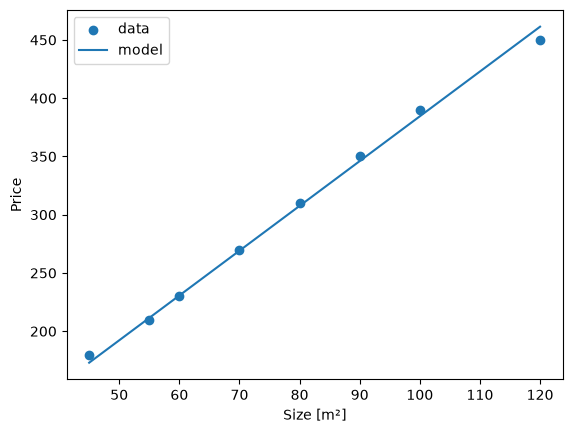

In [26]:
plt.scatter(x, y, label="data")

with torch.no_grad():
    predictions = model(x.reshape(-1, 1))

plt.plot(x, predictions, label="model")
plt.xlabel("Size [m²]")
plt.ylabel("Price")
plt.legend()
plt.show()